# DSAIT4335 Recommender Systems
# Final Project

In this project, you will work to build different recommendation models and evaluate the effectiveness of these models through offline experiments. The dataset used for the experiments is **MovieLens100K**, a movie recommendation dataset collected by GroupLens: https://grouplens.org/datasets/movielens/100k/. For more details, check the project description on Brightspace.

# Instruction

The MovieLens100K is already splitted into 80% training and 20% test sets. Along with training and test sets, movies metadata as content information is also provided.

**Expected file structure** for this assignment:   
   
   ```
   RecSysProject/
   ├── training.txt
   ├── test.txt
   ├── movies.txt
   └── codes.ipynb
   ```

**Note:** Be sure to run all cells in each section sequentially, so that intermediate variables and packages are properly carried over to subsequent cells.

**Note** Be sure to run all cells such that the submitted file contains the output of each cell.

**Note** Feel free to add cells if you need more for answering a question.

**Submission:** Answer all the questions in this jupyter-notebook file. Submit this jupyter-notebook file (your answers included) to Brightspace. Change the name of this jupyter-notebook file to your group number: example, group10 -> 10.ipynb.

# Setup

In [10]:
!pip install transformers torch  # For BERT
# you can refer https://huggingface.co/docs/transformers/en/model_doc/bert for various versions of the pre-trained model BERT

In [11]:
# For BERT embeddings (install: pip install transformers torch)
print("Check the status of BERT installation:")

try:
    from transformers import AutoTokenizer, AutoModel
    import torch
    BERT_AVAILABLE = True
    print("BERT libraries loaded successfully!")
    device = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
except ImportError:
    BERT_AVAILABLE = False
    print("BERT libraries not available. Install with: pip install transformers torch")

Check the status of BERT installation:
BERT libraries loaded successfully!
Using device: mps


In [71]:
import numpy as np
import pandas as pd
import math
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
import time
import os
from tqdm import tqdm
from itertools import product
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from typing import Tuple, List, Dict, Any
import inspect
import random
import warnings
warnings.filterwarnings('ignore')
os.makedirs('preds', exist_ok=True)

# Set random seed for reproducibility
np.random.seed(10)

print("Libraries imported successfully!")


Libraries imported successfully!


# Load dataset

In [49]:
columns_name=['user_id','item_id','rating','timestamp']
train_data = pd.read_csv('training.txt', sep='\t', names=columns_name)
test_data = pd.read_csv('test.txt', sep='\t', names=columns_name)
val_data, test_data = train_test_split(
    test_data,
    test_size=0.8, 
    random_state=10,
    shuffle=True
)

print(f'The training data:')
display(train_data[['user_id','item_id','rating']].head())
print(f'The shape of the training data: {train_data.shape}')
print('--------------------------------')
print(f'The test data:')
display(test_data[['user_id','item_id','rating']].head())
print(f'The shape of the test data: {test_data.shape}')

The training data:


,user_id,item_id,rating
0,1,1,5
1,1,2,3
2,1,3,4
3,1,4,3
4,1,5,3


The shape of the training data: (80000, 4)
--------------------------------
The test data:


,user_id,item_id,rating
19778,435,760,1
4376,91,318,5
10188,224,1053,3
9887,221,1210,3
4441,92,129,4


The shape of the test data: (16000, 4)


In [14]:
movies = pd.read_csv('movies.txt',names=['item_id','title','genres','description'],sep='\t')
movies.head()

,item_id,title,genres,description
0,1,Toy Story (1995),"Animation, Children's, Comedy","A group of sentient toys, who pretend to be li..."
1,2,GoldenEye (1995),"Action, Adventure, Thriller","In 1986, MI6 agents James Bond and Alec Trevel..."
2,3,Four Rooms (1995),Thriller,"On New Year's Eve, bellhop Sam (Marc Lawrence)..."
3,4,Get Shorty (1995),"Action, Comedy, Drama",Chili Palmer is a Miami-based loan shark and m...
4,5,Copycat (1995),"Crime, Drama, Thriller",After giving a guest lecture on criminal psych...


## Task 0) Utilities

### Save Predictions

In [15]:
def save_predictions_to_csv(
    model,
    test_data: pd.DataFrame,
    output_filepath: str,
    model_name: str = "Model",
    **kwargs
) -> pd.DataFrame:
    """
    Generate predictions for test data and save to CSV.
    """
    print(f"Generating predictions using {model_name}...")
    
    predictions_list = []
    
    for _, row in tqdm(test_data[['user_id', 'item_id', 'rating']].iterrows(), 
                       total=len(test_data), 
                       desc=f"{model_name} Predictions"):
        user_id = row['user_id']
        item_id = row['item_id']
        actual_rating = row['rating']
        
        predicted_rating = model.predict_rating(user_id, item_id)
        predicted_rating = float(np.clip(predicted_rating, 1.0, 5.0))
        
        predictions_list.append({
            'user_id': user_id,
            'item_id': item_id,
            'actual_rating': float(actual_rating),
            'predicted_rating': predicted_rating
        })
    
    predictions_df = pd.DataFrame(predictions_list)
    
    rmse = np.sqrt(mean_squared_error(predictions_df['actual_rating'], 
                                       predictions_df['predicted_rating']))
    mae = mean_absolute_error(predictions_df['actual_rating'], 
                               predictions_df['predicted_rating'])
    
    predictions_df.to_csv(output_filepath, index=False)
    
    print(f"\nPredictions saved to: {output_filepath}")
    print(f"Results for {model_name}:")
    print(f"   - Total predictions: {len(predictions_df)}")
    print(f"   - RMSE: {rmse:.4f}")
    print(f"   - MAE: {mae:.4f}")

    return predictions_df

### Calculate Metrics

In [ ]:
def evaluate_rmse(model, test_data: pd.DataFrame) -> float:
    """Evaluate RMSE on test data for any model with predict_rating method."""
    preds = []
    trues = []
    
    for _, row in tqdm(test_data[['user_id', 'item_id', 'rating']].iterrows(), total=len(test_data)):
        u = row['user_id']
        i = row['item_id']
        true_r = row['rating']
        
        pred = model.predict_rating(u, i)
        
        preds.append(float(pred))
        trues.append(float(true_r))
    
    return float(math.sqrt(mean_squared_error(trues, preds)))


def evaluate_ndcg(model, test_data: pd.DataFrame, train_data: pd.DataFrame, n: int = 10) -> float:
    """Evaluate NDCG@N for ranking performance for any model with recommend_topk method."""
    
    def dcg(rels):
        return sum((2.0**float(r) - 1.0) / math.log2(idx + 2.0) for idx, r in enumerate(rels))
    
    ndcg_list = []
    test_users = test_data['user_id'].unique()
    test_group = test_data.groupby('user_id').apply(
        lambda df: df.set_index('item_id')['rating'].to_dict()
    ).to_dict()
    
    for u in tqdm(test_users):
        gt_dict = test_group.get(u, {})
        if len(gt_dict) == 0:
            continue
        
        if 'train_data' in model.recommend_topk.__code__.co_varnames:
            recs = model.recommend_topk(u, train_data, n=n)
        else:
            recs = model.recommend_topk(u, n=n)

        if len(recs) == 0:
            continue
        
        rec_items = [item for item, _ in recs][:n]
        pred_rels = [gt_dict.get(it, 0.0) for it in rec_items]
        ideal_rels = sorted(gt_dict.values(), reverse=True)[:n]
        
        idcg = dcg(ideal_rels)
        if idcg == 0.0:
            continue
        
        dcg_val = dcg(pred_rels)
        ndcg_list.append(dcg_val / idcg)
    
    if len(ndcg_list) == 0:
        return 0.0
    
    return float(np.mean(ndcg_list))

### Hyperparameters Sweep

In [38]:
def hyperparameter_sweep(
    model_class,
    train_data: pd.DataFrame,
    val_data: pd.DataFrame,
    param_grid: dict,
    metric: str = 'rmse'
) -> Tuple[dict, float, dict]:
    """
    Sweep through different hyperparameter combinations and find the best one.
    """
    print(f"\n{'='*60}")
    print(f"Hyperparameter Sweep for {model_class.__name__}")
    print(f"Testing parameters: {param_grid}")
    print(f"Optimization metric: {metric.upper()}")
    print(f"{'='*60}\n")
    
    param_names = list(param_grid.keys())
    param_values = list(param_grid.values())
    results = {}
    
    for param_combo in product(*param_values):
        params = dict(zip(param_names, param_combo))
        
        print(f"\n{'='*40}")
        print(f"Testing: {params}")
        print(f"{'='*40}")
        
        model = model_class(**params)
        fit_signature = inspect.signature(model.fit)
        if 'val_data' in fit_signature.parameters:
            model.fit(train_data, val_data)
        else:
            model.fit(train_data)
        
        measure_set_size = val_data.shape[0]
        if metric == 'rmse':
            score_val = evaluate_rmse(model, val_data, **params)
            print(f"RMSE (Validation) = {score_val:.4f}")
            score_train = evaluate_rmse(model, train_data[:measure_set_size], **params)
            print(f"RMSE (Training) = {score_train:.4f}")
        elif metric == 'ndcg':
            score_val = evaluate_ndcg(model, val_data, train_data, n=10, **params)
            print(f"NDCG@10 (Validation) = {score_val:.4f}")
        else:
            raise ValueError(f"Unknown metric: {metric}. Use 'rmse' or 'ndcg'")
        
        results[str(params)] = {'params': params, metric: score_val}
    
    if metric == 'rmse':
        best_params_str = min(results.keys(), key=lambda k: results[k]['rmse'])
        best_params = results[best_params_str]['params']
        best_score = results[best_params_str]['rmse']
    else:
        best_params_str = max(results.keys(), key=lambda k: results[k]['ndcg'])
        best_params = results[best_params_str]['params']
        best_score = results[best_params_str]['ndcg']
    
    print(f"\n{'='*60}")
    print(f"Best parameters: {best_params}")
    print(f"Best {metric.upper()}: {best_score:.4f}")
    print(f"{'='*60}\n")
    
    return best_params, best_score, results


def train_and_predict_best(
    model_class,
    train_data: pd.DataFrame,
    val_data: pd.DataFrame,
    test_data: pd.DataFrame,
    param_grid: dict,
    output_filepath: str,
    metric: str = 'rmse',
    model_name: Optional[str] = None
) -> Tuple[object, pd.DataFrame]:
    """
    Find best hyperparameters, train model, and generate predictions.
    """
    best_params, best_score, all_results = hyperparameter_sweep(
        model_class, train_data, val_data, param_grid, metric
    )
    
    if model_name is None:
        model_name = f"{model_class.__name__}"
    
    print(f"\n{'='*60}")
    print(f"Training final model with best parameters")
    print(f"Parameters: {best_params}")
    print(f"{'='*60}\n")
    
    final_model = model_class(**best_params)
    fit_signature = inspect.signature(final_model.fit)
    if 'val_data' in fit_signature.parameters:
        final_model.fit(train_data, val_data)
    else:
        final_model.fit(train_data)
    
    predictions_df = save_predictions_to_csv(
        model=final_model,
        test_data=test_data,
        output_filepath=output_filepath,
        model_name=f"{model_name} {best_params}",
        **best_params
    )
    
    print(f"\n{'='*60}")
    print(f"Summary:")
    print(f"  - Best parameters: {best_params}")
    print(f"  - Best {metric.upper()}: {best_score:.4f}")
    print(f"  - Predictions saved to: {output_filepath}")
    print(f"{'='*60}\n")
    
    return final_model, predictions_df

# Task 1) Implementation of different recommendation models as well as a hybrid model combining those recommendation models

### User-based (UserKNN)

In [ ]:
class UserBasedCF:
    """User-Based Collaborative Filtering using Pearson correlation."""

    def __init__(self, k: int = 50):
        self.k = k
        self.train_data = None
        self.user_similarity_matrix = None
        self.users = None
        self.items = None
        self.user_means = None
        self.global_mean = None

    def pearson_correlation(self, user1_ratings: pd.Series, user2_ratings: pd.Series) -> float:
        """Compute Pearson correlation between two users."""
        if user1_ratings is None or user2_ratings is None:
            return 0.0
        common_idx = user1_ratings.index.intersection(user2_ratings.index)
        if len(common_idx) == 0:
            return 0.0
        x = user1_ratings.reindex(common_idx).astype(float)
        y = user2_ratings.reindex(common_idx).astype(float)
        mask = x.notna() & y.notna()
        x = x[mask]
        y = y[mask]
        if x.shape[0] < 2:
            return 0.0
        xm = x.mean()
        ym = y.mean()
        num = ((x - xm) * (y - ym)).sum()
        denom = np.sqrt(((x - xm) ** 2).sum()) * np.sqrt(((y - ym) ** 2).sum())
        if denom == 0.0:
            return 0.0
        return float(num / denom)

    def compute_user_similarity_matrix(self, train_data: pd.DataFrame) -> pd.DataFrame:
        """Compute user-user similarity matrix."""
        users = train_data['user_id'].unique()
        user_similarity_matrix = pd.DataFrame(
            np.zeros((len(users), len(users))), 
            index=users, 
            columns=users
        )
        user_ratings = {
            u: train_data[train_data['user_id'] == u].set_index('item_id')['rating'] 
            for u in users
        }
        for i, u in enumerate(tqdm(users)):
            user_similarity_matrix.at[u, u] = 1.0
            for j in range(i + 1, len(users)):
                v = users[j]
                sim = self.pearson_correlation(user_ratings[u], user_ratings[v])
                user_similarity_matrix.at[u, v] = sim
                user_similarity_matrix.at[v, u] = sim
        return user_similarity_matrix

    def get_k_user_neighbors(self, target_user: int) -> List[Tuple[int, float]]:
        """Get top-k most similar users."""
        if target_user not in self.user_similarity_matrix.index:
            return []
        sims = self.user_similarity_matrix.loc[target_user].drop(labels=target_user, errors='ignore')
        top_series = sims.sort_values(ascending=False).head(self.k)
        return list(top_series.items())

    def predict_rating(self, target_user: int, target_item: int) -> float:
        """Predict rating for a given user and item."""
        if target_user not in self.user_similarity_matrix.index:
            return self.global_mean
        user_mean = self.user_means.get(target_user, self.global_mean)
        neighbors = self.get_k_user_neighbors(target_user)
        num = 0.0
        den = 0.0
        used_neighbors = 0
        for v, s in neighbors:
            row = self.train_data[
                (self.train_data['user_id'] == v) & 
                (self.train_data['item_id'] == target_item)
            ]
            if row.empty:
                continue
            r_vi = float(row['rating'].iloc[0])
            v_mean = self.user_means.get(v, self.global_mean)
            num += s * (r_vi - v_mean)
            den += abs(s)
            used_neighbors += 1
        if used_neighbors == 0 or den == 0.0:
            return float(user_mean)
        result = float(user_mean + num / den)
        return float(np.clip(result, 1.0, 5.0))

    def recommend_topk(self, target_user: int, n: int = 10) -> List[Tuple[int, float]]:
        """Generate top-N recommendations for a user."""
        if target_user not in self.user_similarity_matrix.index:
            return []
        seen_items = set(self.train_data.loc[self.train_data['user_id'] == target_user, 'item_id'].unique())
        candidate_items = self.items - seen_items
        scores = []
        for item in candidate_items:
            pred = self.predict_rating(target_user, item, self.k)
            if np.isnan(pred):
                continue
            scores.append((item, float(pred)))
        scores.sort(key=lambda x: x[1], reverse=True)
        return scores[:n]

    def fit(self, train_data: pd.DataFrame):
        """Fit model by computing user-user similarity matrix."""
        self.train_data = train_data
        self.users = set(train_data['user_id'].unique())
        self.items = set(train_data['item_id'].unique())
        self.global_mean = train_data['rating'].mean()
        self.user_means = train_data.groupby('user_id')['rating'].mean().to_dict()
        self.user_similarity_matrix = self.compute_user_similarity_matrix(train_data)

def train_user_based_cf(train_data: pd.DataFrame, k: int = 50) -> UserBasedCF:
    """Train a User-Based CF model."""
    model = UserBasedCF(k=k)
    model.fit(train_data)
    return model

user_knn_model, user_knn_predictions = train_and_predict_best(
    model_class=UserBasedCF,
    train_data=train_data,
    val_data=val_data,
    test_data=test_data,
    param_grid={'k': [30, 50, 70]},
    output_filepath='preds/predictions_userknn_best.csv',
    metric='rmse'
)


Hyperparameter Sweep for UserBasedCF
Testing parameters: {'k': [30, 50, 70]}
Optimization metric: RMSE


Testing: {'k': 30}


  8%|▊         | 74/943 [00:26<05:01,  2.88it/s]

### Item-based (ItemKNN)

In [81]:
class ItemBasedCF:
    """Item-Based Collaborative Filtering with adaptive fallback."""

    def __init__(self, k: int = 50, min_common: int = 2):  # Changed parameter
        self.k = k
        self.min_common = min_common  # Minimum common users for similarity (not total ratings)
        self.train_data = None
        self.item_similarity_matrix = None
        self.users = None
        self.items = None
        self.user_means = None
        self.global_mean = None
        self.item_means = None  # Add item means

    def cosine_similarity(self, item1_ratings: pd.Series, item2_ratings: pd.Series) -> float:
        """Compute cosine similarity between two items."""
        if item1_ratings is None or item2_ratings is None:
            return 0.0
        
        common_users = item1_ratings.index.intersection(item2_ratings.index)
        
        # Only require minimum overlap, not minimum total ratings
        if len(common_users) < self.min_common:
            return 0.0
            
        x = item1_ratings.reindex(common_users).astype(float)
        y = item2_ratings.reindex(common_users).astype(float)
        mask = x.notna() & y.notna()
        x = x[mask]
        y = y[mask]
        
        if x.size < self.min_common:
            return 0.0
            
        numerator = (x * y).sum()
        denom = np.sqrt((x ** 2).sum()) * np.sqrt((y ** 2).sum())
        if denom == 0.0:
            return 0.0
        return float(numerator / denom)

    def compute_item_similarity_matrix(self, train_data: pd.DataFrame) -> pd.DataFrame:
        """Compute item-item similarity matrix."""
        items = train_data['item_id'].unique()
        
        print(f"Computing similarities for {len(items)} items (min_common={self.min_common})...")
        
        item_similarity_matrix = pd.DataFrame(
            np.zeros((len(items), len(items))),
            index=items,
            columns=items
        )
        
        item_ratings = {
            it: train_data[train_data['item_id'] == it].set_index('user_id')['rating']
            for it in items
        }
        
        for i_idx, i in enumerate(tqdm(items, desc="Computing similarities")):
            item_similarity_matrix.at[i, i] = 1.0
            
            for j in items[i_idx + 1:]:
                sim = self.cosine_similarity(item_ratings[i], item_ratings[j])
                item_similarity_matrix.at[i, j] = sim
                item_similarity_matrix.at[j, i] = sim
                
        return item_similarity_matrix

    def get_k_item_neighbors(self, target_item: int, k: Optional[int] = None) -> List[Tuple[int, float]]:
        """Get top-k most similar items."""
        if k is None:
            k = self.k
        if target_item not in self.item_similarity_matrix.index:
            return []
        sims = self.item_similarity_matrix.loc[target_item].drop(labels=target_item, errors='ignore')
        
        # Only return neighbors with positive similarity
        sims = sims[sims > 0]
        top_series = sims.sort_values(ascending=False).head(k)
        return list(top_series.items())

    def predict_rating(self, target_user: int, target_item: int) -> float:
        """Predict rating with adaptive fallback strategy."""
        
        # Check if item exists in similarity matrix
        if target_item not in self.item_similarity_matrix.index:
            # Fallback 1: Item mean if available
            if target_item in self.item_means:
                return float(np.clip(self.item_means[target_item], 1.0, 5.0))
            # Fallback 2: User mean
            return self.user_means.get(target_user, self.global_mean)
        
        # Get user's ratings
        user_ratings = self.train_data[self.train_data['user_id'] == target_user].set_index('item_id')['rating']
        
        if user_ratings.empty:
            # User not in training set - use item mean or global mean
            return self.item_means.get(target_item, self.global_mean)
        
        # Get neighbors
        all_neighbors = self.get_k_item_neighbors(target_item)
        
        if not all_neighbors:
            # No similar items - use item mean
            return self.item_means.get(target_item, self.user_means.get(target_user, self.global_mean))
        
        # Filter to neighbors rated by this user
        rated_neighbors = [
            (item, sim) for item, sim in all_neighbors 
            if item in user_ratings.index and sim > 0  # Only positive similarities
        ]
        
        if not rated_neighbors:
            # User hasn't rated any similar items - blend item and user means
            item_mean = self.item_means.get(target_item, self.global_mean)
            user_mean = self.user_means.get(target_user, self.global_mean)
            return float(np.clip(0.7 * item_mean + 0.3 * user_mean, 1.0, 5.0))
        
        # Take top k neighbors
        top_neighbors = sorted(rated_neighbors, key=lambda x: x[1], reverse=True)[:self.k]
        
        # Weighted average prediction
        num = 0.0
        den = 0.0
        for item, sim in top_neighbors:
            rating = user_ratings.loc[item]
            if pd.notna(rating) and sim > 0:
                num += sim * rating
                den += sim  # Use sim not abs(sim) since we filter positive
        
        if den == 0.0:
            return self.item_means.get(target_item, self.user_means.get(target_user, self.global_mean))
        
        result = float(num / den)
        return float(np.clip(result, 1.0, 5.0))

    def recommend_topk(self, target_user: int, train_data: Optional[pd.DataFrame] = None, 
                       n: int = 10) -> List[Tuple[int, float]]:
        """Generate top-N recommendations for a user."""
        if train_data is None:
            train_data = self.train_data
            
        if target_user not in train_data['user_id'].unique():
            # Recommend most popular items for cold start users
            popular_items = sorted(
                self.item_means.items(), 
                key=lambda x: x[1], 
                reverse=True
            )[:n]
            return popular_items
            
        seen_items = set(train_data.loc[train_data['user_id'] == target_user, 'item_id'].unique())
        candidate_items = self.items - seen_items
        
        scores = []
        for item in candidate_items:
            pred = self.predict_rating(target_user, item)
            if not np.isnan(pred):
                scores.append((item, float(pred)))
            
        scores.sort(key=lambda x: x[1], reverse=True)
        return scores[:n]

    def fit(self, train_data: pd.DataFrame):
        """Fit model by computing item-item similarity matrix."""
        self.train_data = train_data
        self.users = set(train_data['user_id'].unique())
        self.items = set(train_data['item_id'].unique())
        self.global_mean = train_data['rating'].mean()
        self.user_means = train_data.groupby('user_id')['rating'].mean().to_dict()
        self.item_means = train_data.groupby('item_id')['rating'].mean().to_dict()  # Add item means
        
        print(f"\nDataset statistics:")
        print(f"  Users: {len(self.users)}")
        print(f"  Items: {len(self.items)}")
        print(f"  Ratings: {len(train_data)}")
        print(f"  Density: {len(train_data) / (len(self.users) * len(self.items)) * 100:.2f}%")
        
        self.item_similarity_matrix = self.compute_item_similarity_matrix(train_data)
        return self


# Updated training with better parameters
item_knn_model, item_knn_predictions = train_and_predict_best(
    model_class=ItemBasedCF,
    train_data=train_data,
    val_data=val_data,
    test_data=test_data,
    param_grid={
        'k': [30, 50, 70],
        'min_common': [5, 10, 15]  # Minimum common users for similarity
    },
    output_filepath='preds/predictions_itemknn_best.csv',
    metric='rmse'
)


Hyperparameter Sweep for ItemBasedCF
Testing parameters: {'k': [30, 50, 70], 'min_common': [5, 10, 15]}
Optimization metric: RMSE


Testing: {'k': 30, 'min_common': 5}

Dataset statistics:
  Users: 943
  Items: 1650
  Ratings: 80000
  Density: 5.14%
Computing similarities for 1650 items (min_common=5)...


100%|██████████| 4000/4000 [00:01<00:00, 2337.48it/s]


RMSE (Validation) = 1.1824


100%|██████████| 4000/4000 [00:01<00:00, 2095.02it/s]


RMSE (Training) = 0.9297

Testing: {'k': 30, 'min_common': 10}

Dataset statistics:
  Users: 943
  Items: 1650
  Ratings: 80000
  Density: 5.14%
Computing similarities for 1650 items (min_common=10)...


...

RMSE (Training) = 1.0009

Best parameters: {'k': 70, 'min_common': 10}
Best RMSE: 1.1038


Training final model with best parameters
Parameters: {'k': 70, 'min_common': 10}


Dataset statistics:
  Users: 943
  Items: 1650
  Ratings: 80000
  Density: 5.14%
Computing similarities for 1650 items (min_common=10)...


Computing similarities: 100%|██████████| 1650/1650 [01:53<00:00, 14.52it/s] 


Generating predictions using ItemBasedCF {'k': 70, 'min_common': 10}...


ItemBasedCF {'k': 70, 'min_common': 10} Predictions: 100%|██████████| 16000/16000 [00:07<00:00, 2150.30it/s]



Predictions saved to: preds/predictions_itemknn_best.csv
Results for ItemBasedCF {'k': 70, 'min_common': 10}:
   - Total predictions: 16000
   - RMSE: 1.0997
   - MAE: 0.8490

Summary:
  - Best parameters: {'k': 70, 'min_common': 10}
  - Best RMSE: 1.1038
  - Predictions saved to: preds/predictions_itemknn_best.csv



### Matrix Factorization


Hyperparameter Sweep for MatrixFactorizationSGD
Testing parameters: {'n_factors': [60, 80], 'learning_rate': [0.002], 'n_epochs': [40], 'use_bias': [True], 'eval_every': [5], 'batch_size': [1024], 'device': ['auto'], 'l2_reg': [0.2]}
Optimization metric: RMSE


Testing: {'n_factors': 60, 'learning_rate': 0.002, 'n_epochs': 40, 'use_bias': True, 'eval_every': 5, 'batch_size': 1024, 'device': 'auto', 'l2_reg': 0.2}
Using device: mps
L2 Regularization: 0.2


Training MF: 100%|██████████| 40/40 [00:57<00:00,  1.44s/it]



Best validation RMSE: 0.9372 at epoch 40


100%|██████████| 4000/4000 [00:03<00:00, 1044.03it/s]


RMSE (Validation) = 0.9372


...

RMSE (Training) = 0.8979

Best parameters: {'n_factors': 60, 'learning_rate': 0.002, 'n_epochs': 40, 'use_bias': True, 'eval_every': 5, 'batch_size': 1024, 'device': 'auto', 'l2_reg': 0.2}
Best RMSE: 0.9372


Training final model with best parameters
Parameters: {'n_factors': 60, 'learning_rate': 0.002, 'n_epochs': 40, 'use_bias': True, 'eval_every': 5, 'batch_size': 1024, 'device': 'auto', 'l2_reg': 0.2}

Using device: mps
L2 Regularization: 0.2


Training MF: 100%|██████████| 40/40 [00:59<00:00,  1.48s/it]



Best validation RMSE: 0.9368 at epoch 40
Generating predictions using MatrixFactorizationSGD {'n_factors': 60, 'learning_rate': 0.002, 'n_epochs': 40, 'use_bias': True, 'eval_every': 5, 'batch_size': 1024, 'device': 'auto', 'l2_reg': 0.2}...


MatrixFactorizationSGD {'n_factors': 60, 'learning_rate': 0.002, 'n_epochs': 40, 'use_bias': True, 'eval_every': 5, 'batch_size': 1024, 'device': 'auto', 'l2_reg': 0.2} Predictions: 100%|██████████| 16000/16000 [00:16<00:00, 963.96it/s] 



Predictions saved to: preds/predictions_mf_best.csv
Results for MatrixFactorizationSGD {'n_factors': 60, 'learning_rate': 0.002, 'n_epochs': 40, 'use_bias': True, 'eval_every': 5, 'batch_size': 1024, 'device': 'auto', 'l2_reg': 0.2}:
   - Total predictions: 16000
   - RMSE: 0.9403
   - MAE: 0.7429

Summary:
  - Best parameters: {'n_factors': 60, 'learning_rate': 0.002, 'n_epochs': 40, 'use_bias': True, 'eval_every': 5, 'batch_size': 1024, 'device': 'auto', 'l2_reg': 0.2}
  - Best RMSE: 0.9372
  - Predictions saved to: preds/predictions_mf_best.csv



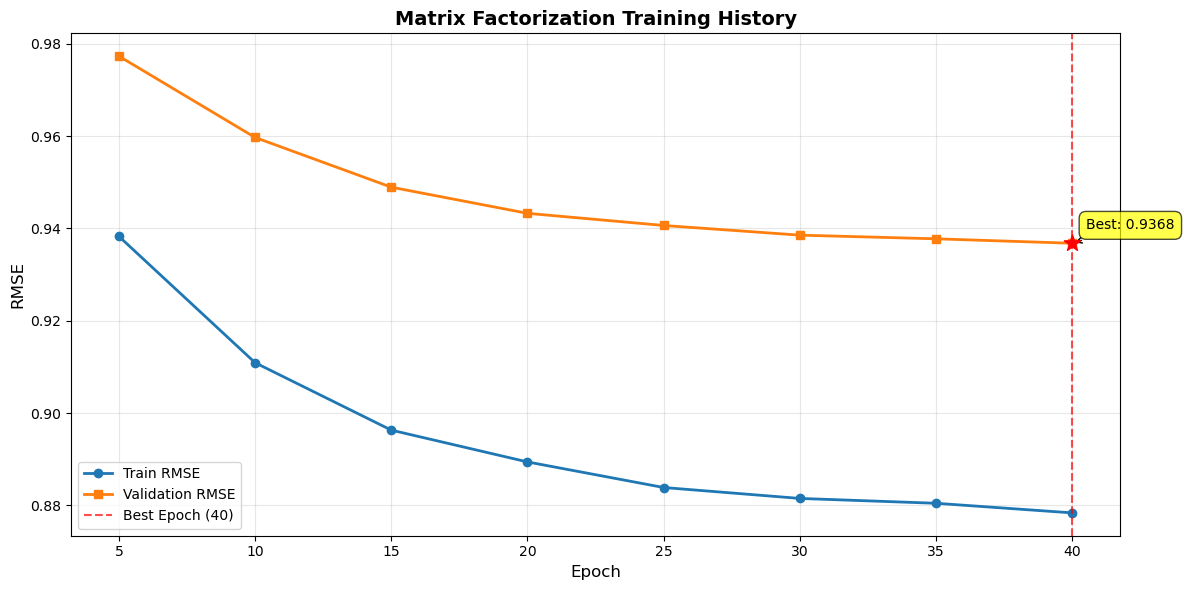


Training Summary:
Final Train RMSE: 0.8784
Final Val RMSE: 0.9368
Best Val RMSE: 0.9368 (Epoch 40)
No overfitting detected

No retraining needed - using existing model


In [79]:
class RatingDataset(Dataset):
    """PyTorch Dataset for ratings."""
    
    def __init__(self, user_ids, item_ids, ratings):
        self.users = torch.LongTensor(user_ids)
        self.items = torch.LongTensor(item_ids)
        self.ratings = torch.FloatTensor(ratings)
    
    def __len__(self):
        return len(self.ratings)
    
    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.ratings[idx]


class MatrixFactorizationSGD:
    """Matrix Factorization with PyTorch for GPU acceleration and L2 regularization."""

    def __init__(self, n_factors, learning_rate, n_epochs, use_bias, eval_every, 
                 batch_size=1024, device='auto', l2_reg=0.01):
        self.n_factors = n_factors
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.use_bias = use_bias
        self.eval_every = eval_every
        self.batch_size = batch_size
        self.l2_reg = l2_reg  # L2 regularization strength
        
        # Device selection
        if device == 'auto':
            self.device = torch.device('mps' if torch.backends.mps.is_available() 
                                      else 'cuda' if torch.cuda.is_available() 
                                      else 'cpu')
        else:
            self.device = torch.device(device)
        
        print(f"Using device: {self.device}")
        print(f"L2 Regularization: {self.l2_reg}")
        
        # Model components
        self.P = None  # User embeddings
        self.Q = None  # Item embeddings
        self.user_bias = None
        self.item_bias = None
        self.global_mean = None
        self.user_mapping = None
        self.item_mapping = None
        self.user_inv = None
        self.item_inv = None
        
        # Training history
        self.history = {
            'train_rmse': [],
            'val_rmse': [],
            'epochs': []
        }
        self.best_epoch = None
        self.best_val_rmse = float('inf')

    def _initialize_model(self, train_data: pd.DataFrame):
        """Initialize model parameters and mappings."""
        self.user_mapping = {u: i for i, u in enumerate(train_data['user_id'].unique())}
        self.item_mapping = {i: j for j, i in enumerate(train_data['item_id'].unique())}
        self.user_inv = {i: u for u, i in self.user_mapping.items()}
        self.item_inv = {j: i for i, j in self.item_mapping.items()}

        n_users = len(self.user_mapping)
        n_items = len(self.item_mapping)

        # Initialize embeddings as PyTorch Embedding layers
        self.P = nn.Embedding(n_users, self.n_factors).to(self.device)
        self.Q = nn.Embedding(n_items, self.n_factors).to(self.device)
        
        # Xavier initialization (slightly smaller for regularization)
        nn.init.normal_(self.P.weight, mean=0, std=0.01)
        nn.init.normal_(self.Q.weight, mean=0, std=0.01)

        if self.use_bias:
            self.user_bias = nn.Embedding(n_users, 1).to(self.device)
            self.item_bias = nn.Embedding(n_items, 1).to(self.device)
            nn.init.zeros_(self.user_bias.weight)
            nn.init.zeros_(self.item_bias.weight)
            self.global_mean = float(train_data['rating'].mean())

    def _prepare_training_data(self, train_data: pd.DataFrame):
        """Convert training data to PyTorch Dataset."""
        user_ids = [self.user_mapping[u] for u in train_data['user_id']]
        item_ids = [self.item_mapping[i] for i in train_data['item_id']]
        ratings = train_data['rating'].values
        
        return RatingDataset(user_ids, item_ids, ratings)

    def _train_one_epoch(self, dataloader, optimizer) -> float:
        """Train for one epoch using mini-batches with L2 regularization."""
        self.P.train()
        self.Q.train()
        if self.use_bias:
            self.user_bias.train()
            self.item_bias.train()
        
        total_loss = 0.0
        n_batches = 0
        
        for users, items, ratings in dataloader:
            users = users.to(self.device)
            items = items.to(self.device)
            ratings = ratings.to(self.device)
            
            # Forward pass
            user_emb = self.P(users)  # [batch_size, n_factors]
            item_emb = self.Q(items)  # [batch_size, n_factors]
            
            # Dot product
            preds = (user_emb * item_emb).sum(dim=1)  # [batch_size]
            
            # Add biases
            if self.use_bias:
                preds = preds + self.global_mean
                preds = preds + self.user_bias(users).squeeze()
                preds = preds + self.item_bias(items).squeeze()
            
            # MSE loss
            mse_loss = nn.functional.mse_loss(preds, ratings)
            
            # L2 regularization on embeddings
            l2_loss = 0.0
            if self.l2_reg > 0:
                # Regularize only the embeddings used in this batch
                l2_loss = (
                    self.l2_reg * (user_emb.pow(2).sum() + item_emb.pow(2).sum())
                ) / users.size(0)
                
                # Optionally regularize biases (usually smaller weight)
                if self.use_bias:
                    l2_loss += (
                        self.l2_reg * 0.1 * (
                            self.user_bias(users).pow(2).sum() + 
                            self.item_bias(items).pow(2).sum()
                        )
                    ) / users.size(0)
            
            # Total loss
            loss = mse_loss + l2_loss
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += mse_loss.item()  # Track MSE for RMSE calculation
            n_batches += 1
        
        return np.sqrt(total_loss / n_batches)

    def _should_evaluate(self, epoch: int) -> bool:
        """Check if we should evaluate at this epoch."""
        return (epoch + 1) % self.eval_every == 0 or (epoch + 1) == self.n_epochs

    def _compute_rmse(self, data: pd.DataFrame) -> float:
        """Compute RMSE on a dataset using GPU-accelerated prediction."""
        self.P.eval()
        self.Q.eval()
        if self.use_bias:
            self.user_bias.eval()
            self.item_bias.eval()
        
        preds = []
        trues = []
        
        with torch.no_grad():
            for _, row in data[['user_id', 'item_id', 'rating']].iterrows():
                pred = self.predict_rating(row['user_id'], row['item_id'])
                preds.append(float(pred))
                trues.append(float(row['rating']))
        
        return float(np.sqrt(mean_squared_error(trues, preds)))

    def _track_metrics(self, epoch: int, train_rmse: float, val_data: pd.DataFrame):
        """Track training metrics and update history."""
        self.history['train_rmse'].append(train_rmse)
        self.history['epochs'].append(epoch + 1)
        
        if val_data is not None:
            val_rmse = self._compute_rmse(val_data)
            self.history['val_rmse'].append(val_rmse)
            if val_rmse < self.best_val_rmse:
                self.best_val_rmse = val_rmse
                self.best_epoch = epoch + 1

    def fit(self, train_data: pd.DataFrame, val_data: pd.DataFrame):
        """Train the model with mini-batch SGD using PyTorch."""
        self._initialize_model(train_data)
        dataset = self._prepare_training_data(train_data)
        dataloader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)
        
        # Optimizer (weight_decay can also be used but we implement custom L2)
        params = list(self.P.parameters()) + list(self.Q.parameters())
        if self.use_bias:
            params += list(self.user_bias.parameters()) + list(self.item_bias.parameters())
        
        optimizer = optim.Adam(params, lr=self.learning_rate)
        
        # Reset history
        self.history = {'train_rmse': [], 'val_rmse': [], 'epochs': []}
        self.best_val_rmse = float('inf')
        self.best_epoch = None
        
        # Training loop
        for epoch in tqdm(range(self.n_epochs), desc="Training MF"):
            train_rmse = self._train_one_epoch(dataloader, optimizer)
            
            if self._should_evaluate(epoch):
                self._track_metrics(epoch, train_rmse, val_data)
        
        if self.best_epoch is not None:
            print(f"\nBest validation RMSE: {self.best_val_rmse:.4f} at epoch {self.best_epoch}")
        
        return self

    def predict_rating(self, user_id: int, item_id: int) -> float:
        """Predict a single user–item rating using GPU."""
        if user_id not in self.user_mapping or item_id not in self.item_mapping:
            return self.global_mean if self.use_bias else 3.0
        
        self.P.eval()
        self.Q.eval()
        if self.use_bias:
            self.user_bias.eval()
            self.item_bias.eval()
        
        with torch.no_grad():
            u = torch.LongTensor([self.user_mapping[user_id]]).to(self.device)
            i = torch.LongTensor([self.item_mapping[item_id]]).to(self.device)
            
            user_emb = self.P(u)
            item_emb = self.Q(i)
            
            pred = torch.dot(user_emb[0], item_emb[0]).item()
            
            if self.use_bias:
                pred += self.global_mean
                pred += self.user_bias(u).item()
                pred += self.item_bias(i).item()
        
        return float(np.clip(pred, 1.0, 5.0))

    def recommend_topk(self, user_id: int, train_data: pd.DataFrame, n: int = 10, 
                       exclude_seen: bool = True) -> List[Tuple[int, float]]:
        """Generate top-N recommendations for a user using GPU."""
        if user_id not in self.user_mapping:
            return []
        
        self.P.eval()
        self.Q.eval()
        if self.use_bias:
            self.user_bias.eval()
            self.item_bias.eval()
        
        with torch.no_grad():
            u = torch.LongTensor([self.user_mapping[user_id]]).to(self.device)
            user_emb = self.P(u)  # [1, n_factors]
            
            # Compute scores for all items
            scores = torch.matmul(user_emb, self.Q.weight.T)[0]  # [n_items]
            
            if self.use_bias:
                scores = scores + self.global_mean
                scores = scores + self.user_bias(u).item()
                scores = scores + self.item_bias.weight.squeeze()
            
            scores = scores.cpu().numpy()
        
        if exclude_seen:
            seen_items = train_data[train_data['user_id'] == user_id]['item_id'].values
            seen_idx = [self.item_mapping[i] for i in seen_items if i in self.item_mapping]
            scores[seen_idx] = -np.inf
        
        top_idx = np.argsort(scores)[::-1][:n]
        top_items = [self.item_inv[i] for i in top_idx]
        top_scores = scores[top_idx]
        
        return list(zip(top_items, top_scores))
    
    def get_training_history(self) -> Dict:
        """Return training history."""
        return self.history
    
    def get_best_epoch(self) -> Optional[int]:
        """Return the epoch with best validation RMSE."""
        return self.best_epoch
    
    def plot_training_history(self, figsize=(12, 6), save_path=None):
        """Plot training and validation loss curves."""
        if not self.history['epochs']:
            print("No training history available. Train the model first.")
            return
        
        plt.figure(figsize=figsize)
        
        plt.plot(self.history['epochs'], self.history['train_rmse'], 
                label='Train RMSE', marker='o', linewidth=2, markersize=6)
        
        if self.history['val_rmse']:
            plt.plot(self.history['epochs'], self.history['val_rmse'], 
                    label='Validation RMSE', marker='s', linewidth=2, markersize=6)
            
            if self.best_epoch is not None:
                best_idx = self.history['epochs'].index(self.best_epoch)
                best_val_rmse = self.history['val_rmse'][best_idx]
                
                plt.axvline(x=self.best_epoch, color='red', linestyle='--', 
                           label=f'Best Epoch ({self.best_epoch})', alpha=0.7)
                plt.scatter([self.best_epoch], [best_val_rmse], 
                           color='red', s=150, zorder=5, marker='*')
                
                plt.annotate(f'Best: {best_val_rmse:.4f}',
                           xy=(self.best_epoch, best_val_rmse),
                           xytext=(10, 10), textcoords='offset points',
                           bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.7),
                           arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))
        
        plt.xlabel('Epoch', fontsize=12)
        plt.ylabel('RMSE', fontsize=12)
        plt.title('Matrix Factorization Training History', fontsize=14, fontweight='bold')
        plt.legend(fontsize=10)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Plot saved to: {save_path}")
        
        plt.show()
        
        if self.history['val_rmse']:
            final_val_rmse = self.history['val_rmse'][-1]
            print("\n" + "="*60)
            print("Training Summary:")
            print("="*60)
            print(f"Final Train RMSE: {self.history['train_rmse'][-1]:.4f}")
            print(f"Final Val RMSE: {final_val_rmse:.4f}")
            print(f"Best Val RMSE: {self.best_val_rmse:.4f} (Epoch {self.best_epoch})")
            
            if final_val_rmse > self.best_val_rmse:
                diff = final_val_rmse - self.best_val_rmse
                pct = (diff / self.best_val_rmse) * 100
                print(f"Overfitting detected: +{diff:.4f} ({pct:.2f}%)")
            else:
                print("No overfitting detected")
            print("="*60)


# Updated training with regularization
mf_model, mf_predictions = train_and_predict_best(
    model_class=MatrixFactorizationSGD,
    train_data=train_data,
    val_data=val_data,
    test_data=test_data,
    param_grid={
        'n_factors': [60, 80],
        'learning_rate': [0.002],
        'n_epochs': [40],
        'use_bias': [True],
        'eval_every': [5],
        'batch_size': [1024],
        'device': ['auto'],
        'l2_reg': [0.2]  # Test different regularization strengths
    },
    output_filepath='preds/predictions_mf_best.csv',
    metric='rmse'
)

mf_model.plot_training_history()
optimal_epochs = mf_model.get_best_epoch()

# Check if we need to retrain
should_retrain = optimal_epochs is not None and optimal_epochs < mf_model.n_epochs

if should_retrain:
    print("\n" + "="*80)
    print("STEP 3: Retraining with optimal number of epochs")
    print("="*80)
    print(f"Optimal epoch found: {optimal_epochs}")
    print(f"Best validation RMSE: {mf_model.best_val_rmse:.4f}")
    print(f"\nRetraining model with {optimal_epochs} epochs...")

    mf_final = MatrixFactorizationSGD(
        n_factors=mf_model.n_factors,
        learning_rate=mf_model.learning_rate,
        n_epochs=optimal_epochs,
        use_bias=mf_model.use_bias,
        eval_every=mf_model.eval_every,
        batch_size=mf_model.batch_size,
        l2_reg=mf_model.l2_reg,  # Use same regularization
        device='auto'
    ).fit(train_data, val_data)

    print("\n" + "="*80)
    print("Training completed!")
    print("="*80)
    print(f"Final model trained with {optimal_epochs} epochs")
    print(f"Validation RMSE: {mf_final.best_val_rmse:.4f}")
    print("="*80)
else:
    print("\n" + "="*80)
    print("No retraining needed - using existing model")
    print("="*80)
    mf_final = mf_model

### Bayesian Probabilistic Ranking


Hyperparameter Sweep for BayesianProbabilisticRanking
Testing parameters: {'n_factors': [50, 70], 'learning_rate': [0.002], 'n_epochs': [30], 'n_samples': [5, 10], 'eval_every': [5], 'batch_size': [512], 'device': ['auto'], 'l2_reg': [0.1]}
Optimization metric: RMSE


Testing: {'n_factors': 50, 'learning_rate': 0.002, 'n_epochs': 30, 'n_samples': 5, 'eval_every': 5, 'batch_size': 512, 'device': 'auto', 'l2_reg': 0.1}
Using device: mps
L2 Regularization: 0.1
Global mean: 3.5284


Training BPR:   0%|          | 0/30 [00:00<?, ?it/s]

Training BPR:   3%|▎         | 1/30 [00:14<06:46, 14.02s/it]

Epoch 1/30 - Loss: 0.5062 - Val RMSE: 1.1519


Training BPR:  17%|█▋        | 5/30 [00:57<04:48, 11.55s/it]

...

Epoch 25/30 - Loss: 0.4632 - Val RMSE: 1.1474


Training BPR: 100%|██████████| 30/30 [05:08<00:00, 10.28s/it]


Epoch 30/30 - Loss: 0.4635 - Val RMSE: 1.1492

Best validation RMSE: 1.1472 at epoch 10
Generating predictions using BayesianProbabilisticRanking {'n_factors': 50, 'learning_rate': 0.002, 'n_epochs': 30, 'n_samples': 5, 'eval_every': 5, 'batch_size': 512, 'device': 'auto', 'l2_reg': 0.1}...


BayesianProbabilisticRanking {'n_factors': 50, 'learning_rate': 0.002, 'n_epochs': 30, 'n_samples': 5, 'eval_every': 5, 'batch_size': 512, 'device': 'auto', 'l2_reg': 0.1} Predictions: 100%|██████████| 16000/16000 [00:14<00:00, 1093.32it/s]



Predictions saved to: preds/predictions_bpr_best.csv
Results for BayesianProbabilisticRanking {'n_factors': 50, 'learning_rate': 0.002, 'n_epochs': 30, 'n_samples': 5, 'eval_every': 5, 'batch_size': 512, 'device': 'auto', 'l2_reg': 0.1}:
   - Total predictions: 16000
   - RMSE: 1.1581
   - MAE: 0.9078

Summary:
  - Best parameters: {'n_factors': 50, 'learning_rate': 0.002, 'n_epochs': 30, 'n_samples': 5, 'eval_every': 5, 'batch_size': 512, 'device': 'auto', 'l2_reg': 0.1}
  - Best RMSE: 1.1496
  - Predictions saved to: preds/predictions_bpr_best.csv



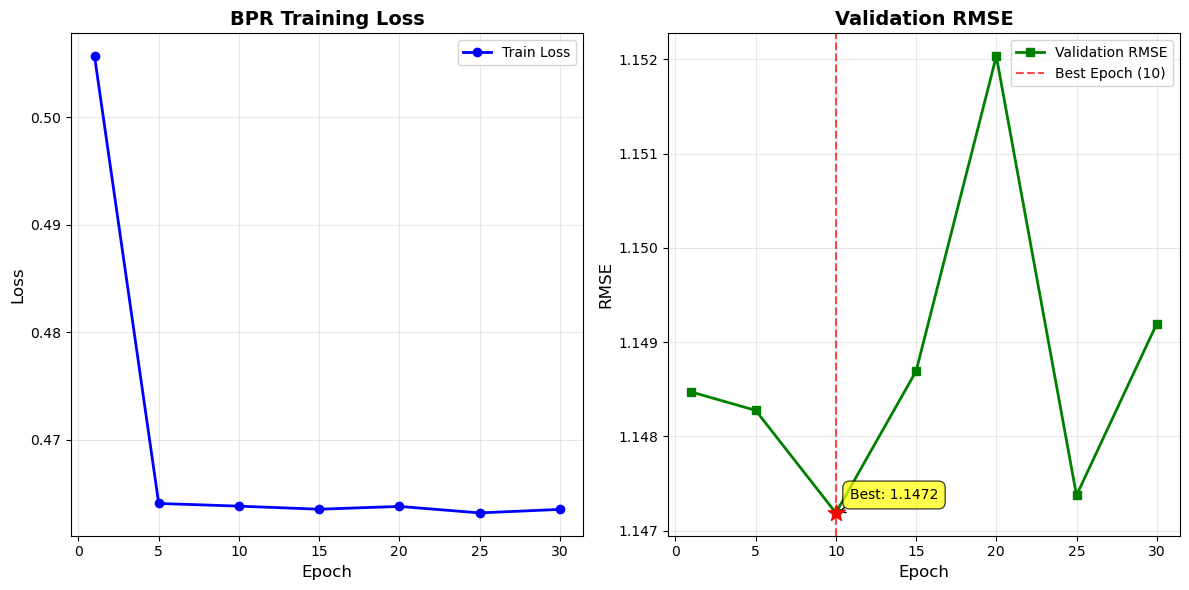


Training Summary:
Final Train Loss: 0.4635
Final Val RMSE: 1.1492
Best Val RMSE: 1.1472 (Epoch 10)
Overfitting detected: +0.0020 (0.17%)

STEP 3: Retraining BPR with optimal number of epochs
Optimal epoch found: 10
Best validation RMSE: 1.1472

Retraining model with 10 epochs...
Using device: mps
L2 Regularization: 0.1
Global mean: 3.5284


Training BPR:  10%|█         | 1/10 [00:12<01:55, 12.80s/it]

Epoch 1/10 - Loss: 0.5054 - Val RMSE: 1.1517


Training BPR:  50%|█████     | 5/10 [00:54<00:54, 10.99s/it]

Epoch 5/10 - Loss: 0.4643 - Val RMSE: 1.1489


Training BPR: 100%|██████████| 10/10 [01:44<00:00, 10.46s/it]

Epoch 10/10 - Loss: 0.4631 - Val RMSE: 1.1532

Best validation RMSE: 1.1489 at epoch 5

BPR Training completed!
Final model trained with 10 epochs
Validation RMSE: 1.1489


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

class BPRDataset(Dataset):
    
    def __init__(self, triples):
        self.triples = torch.LongTensor(triples)
    
    def __len__(self):
        return len(self.triples)
    
    def __getitem__(self, idx):
        return self.triples[idx]


class BayesianProbabilisticRanking:
    """Bayesian Personalized Ranking with L2 regularization."""

    def __init__(self, n_factors, learning_rate, n_epochs, n_samples, eval_every, 
                 batch_size, device, l2_reg=0.01):
        self.n_factors = n_factors
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.n_samples = n_samples
        self.eval_every = eval_every
        self.batch_size = batch_size
        self.l2_reg = l2_reg  # L2 regularization strength
        
        if device == 'auto':
            self.device = torch.device('mps' if torch.backends.mps.is_available() 
                                      else 'cuda' if torch.cuda.is_available() 
                                      else 'cpu')
        else:
            self.device = torch.device(device)
        
        print(f"Using device: {self.device}")
        print(f"L2 Regularization: {self.l2_reg}")
        
        self.P = None
        self.Q = None
        self.user_bias = None
        self.item_bias = None
        self.user_mapping = None
        self.item_mapping = None
        self.user_inv = None
        self.item_inv = None
        self.global_mean = None
        self.user_means = None
        
        self.history = {
            'train_loss': [],
            'val_rmse': [],
            'epochs': []
        }
        self.best_epoch = None
        self.best_val_rmse = float('inf')

    def _generate_training_triples(self, ratings):
        triples = []
        user_items = ratings.groupby('user_id')['item_id'].apply(set).to_dict()
        all_items = set(ratings['item_id'].unique())

        for user_id, rated_items in user_items.items():
            user_idx = self.user_mapping[user_id]
            unrated_items = list(all_items - rated_items)
            if len(unrated_items) == 0:
                continue
            
            rated_items_list = list(rated_items)
            for pos_item_id in rated_items_list:
                pos_item_idx = self.item_mapping[pos_item_id]
                n_neg = min(self.n_samples, len(unrated_items))
                neg_item_ids = np.random.choice(unrated_items, size=n_neg, replace=False)
                for neg_item_id in neg_item_ids:
                    neg_item_idx = self.item_mapping[neg_item_id]
                    triples.append([user_idx, pos_item_idx, neg_item_idx])
        
        return np.array(triples)

    def _should_evaluate(self, epoch):
        return (epoch + 1) % self.eval_every == 0 or (epoch + 1) == self.n_epochs or epoch == 0

    def _compute_rmse_gpu(self, data):
        self.P.eval()
        self.Q.eval()
        if self.user_bias is not None:
            self.user_bias.eval()
            self.item_bias.eval()
        
        user_ids = []
        item_ids = []
        true_ratings = []
        
        for _, row in data[['user_id', 'item_id', 'rating']].iterrows():
            user_ids.append(row['user_id'])
            item_ids.append(row['item_id'])
            true_ratings.append(row['rating'])
        
        preds = []
        batch_size = 1000
        for i in range(0, len(user_ids), batch_size):
            batch_users = user_ids[i:i+batch_size]
            batch_items = item_ids[i:i+batch_size]
            
            batch_preds = []
            for u, it in zip(batch_users, batch_items):
                pred = self.predict_rating(u, it)
                batch_preds.append(pred)
            
            preds.extend(batch_preds)
        
        preds = np.array(preds)
        true_ratings = np.array(true_ratings)
        
        return float(np.sqrt(mean_squared_error(true_ratings, preds)))

    def _track_metrics(self, epoch, avg_loss, val_data):
        self.history['train_loss'].append(avg_loss)
        self.history['epochs'].append(epoch + 1)
        
        if val_data is not None:
            val_rmse = self._compute_rmse_gpu(val_data)
            self.history['val_rmse'].append(val_rmse)
            
            if val_rmse < self.best_val_rmse:
                self.best_val_rmse = val_rmse
                self.best_epoch = epoch + 1

    def fit(self, ratings, val_data):
        self.user_mapping = {u: i for i, u in enumerate(ratings['user_id'].unique())}
        self.item_mapping = {i: j for j, i in enumerate(ratings['item_id'].unique())}
        self.user_inv = {i: u for u, i in self.user_mapping.items()}
        self.item_inv = {j: i for i, j in self.item_mapping.items()}

        self.global_mean = float(ratings['rating'].mean())
        self.user_means = ratings.groupby('user_id')['rating'].mean().to_dict()
        print(f"Global mean: {self.global_mean:.4f}")
        
        n_users = len(self.user_mapping)
        n_items = len(self.item_mapping)

        # Initialize embeddings (smaller std for regularization)
        self.P = torch.nn.Embedding(n_users, self.n_factors).to(self.device)
        self.Q = torch.nn.Embedding(n_items, self.n_factors).to(self.device)
        
        torch.nn.init.normal_(self.P.weight, mean=0, std=0.01)
        torch.nn.init.normal_(self.Q.weight, mean=0, std=0.01)

        # Add bias terms for better rating prediction
        self.user_bias = torch.nn.Embedding(n_users, 1).to(self.device)
        self.item_bias = torch.nn.Embedding(n_items, 1).to(self.device)
        torch.nn.init.zeros_(self.user_bias.weight)
        torch.nn.init.zeros_(self.item_bias.weight)

        optimizer = optim.Adam(
            list(self.P.parameters()) + 
            list(self.Q.parameters()) +
            list(self.user_bias.parameters()) +
            list(self.item_bias.parameters()),
            lr=self.learning_rate
        )

        self.history = {'train_loss': [], 'val_rmse': [], 'epochs': []}
        self.best_val_rmse = float('inf')
        self.best_epoch = None

        for epoch in tqdm(range(self.n_epochs), desc="Training BPR"):
            self.P.train()
            self.Q.train()
            self.user_bias.train()
            self.item_bias.train()
            
            triples = self._generate_training_triples(ratings)
            np.random.shuffle(triples)
            
            dataset = BPRDataset(triples)
            dataloader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)
            
            epoch_loss = 0.0
            n_batches = 0
            
            for batch in dataloader:
                batch = batch.to(self.device)
                users = batch[:, 0]
                pos_items = batch[:, 1]
                neg_items = batch[:, 2]
                
                user_emb = self.P(users)
                pos_item_emb = self.Q(pos_items)
                neg_item_emb = self.Q(neg_items)
                
                pos_scores = (user_emb * pos_item_emb).sum(dim=1)
                neg_scores = (user_emb * neg_item_emb).sum(dim=1)
                
                # BPR ranking loss
                bpr_loss = -torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-10).mean()
                
                # L2 regularization
                l2_loss = 0.0
                if self.l2_reg > 0:
                    # Regularize embeddings used in this batch
                    l2_loss = (
                        self.l2_reg * (
                            user_emb.pow(2).sum() + 
                            pos_item_emb.pow(2).sum() + 
                            neg_item_emb.pow(2).sum()
                        )
                    ) / users.size(0)
                    
                    # Optionally regularize biases (smaller weight)
                    l2_loss += (
                        self.l2_reg * 0.1 * (
                            self.user_bias(users).pow(2).sum() +
                            self.item_bias(pos_items).pow(2).sum() +
                            self.item_bias(neg_items).pow(2).sum()
                        )
                    ) / users.size(0)
                
                # Total loss
                loss = bpr_loss + l2_loss
                
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                
                epoch_loss += bpr_loss.item()  # Track BPR loss only
                n_batches += 1
            
            avg_loss = epoch_loss / n_batches if n_batches > 0 else 0.0
            
            if self._should_evaluate(epoch):
                self._track_metrics(epoch, avg_loss, val_data)
                if self.history['val_rmse']:
                    print(f"Epoch {epoch+1}/{self.n_epochs} - Loss: {avg_loss:.4f} - Val RMSE: {self.history['val_rmse'][-1]:.4f}")
        
        if self.best_epoch is not None:
            print(f"\nBest validation RMSE: {self.best_val_rmse:.4f} at epoch {self.best_epoch}")
        
        return self

    def predict_rating(self, user_id, item_id):
        """Predict rating using bias terms for better accuracy."""
        if user_id not in self.user_mapping or item_id not in self.item_mapping:
            if user_id in self.user_means:
                return float(self.user_means[user_id])
            return float(self.global_mean)
        
        self.P.eval()
        self.Q.eval()
        self.user_bias.eval()
        self.item_bias.eval()
        
        with torch.no_grad():
            u = torch.LongTensor([self.user_mapping[user_id]]).to(self.device)
            i = torch.LongTensor([self.item_mapping[item_id]]).to(self.device)
            
            user_emb = self.P(u)
            item_emb = self.Q(i)
            
            # Rating = global_mean + user_bias + item_bias + dot_product
            score = (
                self.global_mean +
                self.user_bias(u).item() +
                self.item_bias(i).item() +
                torch.dot(user_emb[0], item_emb[0]).item()
            )
            
            return float(np.clip(score, 1.0, 5.0))

    def recommend_topk(self, user_id, train_data, n=10, exclude_seen=True):
        """Generate top-N recommendations for ranking tasks."""
        if user_id not in self.user_mapping:
            return []
        
        self.P.eval()
        self.Q.eval()
        
        with torch.no_grad():
            u = torch.LongTensor([self.user_mapping[user_id]]).to(self.device)
            user_emb = self.P(u)
            
            # Ranking scores (without biases for purer ranking)
            scores = torch.matmul(user_emb, self.Q.weight.T)[0].cpu().numpy()
        
        if exclude_seen:
            seen_items = train_data[train_data['user_id'] == user_id]['item_id'].values
            seen_idx = [self.item_mapping[i] for i in seen_items if i in self.item_mapping]
            scores[seen_idx] = -np.inf
        
        top_idx = np.argsort(scores)[::-1][:n]
        top_items = [self.item_inv[i] for i in top_idx]
        top_scores = scores[top_idx]
        
        return list(zip(top_items, top_scores))

    def get_training_history(self):
        return self.history
    
    def get_best_epoch(self):
        return self.best_epoch
    
    def plot_training_history(self, figsize=(12, 6), save_path=None):
        if not self.history['epochs']:
            print("No training history available. Train the model first.")
            return
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
        
        ax1.plot(self.history['epochs'], self.history['train_loss'], 
                label='Train Loss', marker='o', linewidth=2, markersize=6, color='blue')
        ax1.set_xlabel('Epoch', fontsize=12)
        ax1.set_ylabel('Loss', fontsize=12)
        ax1.set_title('BPR Training Loss', fontsize=14, fontweight='bold')
        ax1.legend(fontsize=10)
        ax1.grid(True, alpha=0.3)
        
        if self.history['val_rmse']:
            ax2.plot(self.history['epochs'], self.history['val_rmse'], 
                    label='Validation RMSE', marker='s', linewidth=2, markersize=6, color='green')
            
            if self.best_epoch is not None:
                best_idx = self.history['epochs'].index(self.best_epoch)
                best_val_rmse = self.history['val_rmse'][best_idx]
                
                ax2.axvline(x=self.best_epoch, color='red', linestyle='--', 
                           label=f'Best Epoch ({self.best_epoch})', alpha=0.7)
                ax2.scatter([self.best_epoch], [best_val_rmse], 
                           color='red', s=150, zorder=5, marker='*')
                
                ax2.annotate(f'Best: {best_val_rmse:.4f}',
                           xy=(self.best_epoch, best_val_rmse),
                           xytext=(10, 10), textcoords='offset points',
                           bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.7),
                           arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))
            
            ax2.set_xlabel('Epoch', fontsize=12)
            ax2.set_ylabel('RMSE', fontsize=12)
            ax2.set_title('Validation RMSE', fontsize=14, fontweight='bold')
            ax2.legend(fontsize=10)
            ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Plot saved to: {save_path}")
        
        plt.show()
        
        if self.history['val_rmse']:
            final_val_rmse = self.history['val_rmse'][-1]
            print("\n" + "="*60)
            print("Training Summary:")
            print("="*60)
            print(f"Final Train Loss: {self.history['train_loss'][-1]:.4f}")
            print(f"Final Val RMSE: {final_val_rmse:.4f}")
            print(f"Best Val RMSE: {self.best_val_rmse:.4f} (Epoch {self.best_epoch})")
            
            if final_val_rmse > self.best_val_rmse:
                diff = final_val_rmse - self.best_val_rmse
                pct = (diff / self.best_val_rmse) * 100
                print(f"Overfitting detected: +{diff:.4f} ({pct:.2f}%)")
            else:
                print("No overfitting detected")
            print("="*60)


# Training with regularization
bpr_model, bpr_predictions = train_and_predict_best(
    model_class=BayesianProbabilisticRanking,
    train_data=train_data,
    val_data=val_data,
    test_data=test_data,
    param_grid={
        'n_factors': [50, 70],
        'learning_rate': [0.001, 0.01],
        'n_epochs': [30],
        'n_samples': [5, 10],
        'eval_every': [5],
        'batch_size': [512],
        'device': ['auto'],
        'l2_reg': [0.1]  # Test different regularization strengths
    },
    output_filepath='preds/predictions_bpr_best.csv',
    metric='rmse'
)

bpr_model.plot_training_history(figsize=(12, 6), save_path=None)
optimal_epochs_bpr = bpr_model.get_best_epoch()

# Check if we need to retrain
should_retrain = (
    optimal_epochs_bpr is not None and 
    optimal_epochs_bpr < bpr_model.n_epochs
)

if should_retrain:
    print("\n" + "="*80)
    print("STEP 3: Retraining BPR with optimal number of epochs")
    print("="*80)
    print(f"Optimal epoch found: {optimal_epochs_bpr}")
    print(f"Best validation RMSE: {bpr_model.best_val_rmse:.4f}")
    print(f"\nRetraining model with {optimal_epochs_bpr} epochs...")

    bpr_final = BayesianProbabilisticRanking(
        n_factors=bpr_model.n_factors,
        learning_rate=bpr_model.learning_rate,
        n_epochs=optimal_epochs_bpr,
        n_samples=bpr_model.n_samples,
        eval_every=bpr_model.eval_every,
        batch_size=bpr_model.batch_size,
        l2_reg=bpr_model.l2_reg,  # Use same regularization
        device='auto'
    ).fit(train_data, val_data)

    print("\n" + "="*80)
    print("BPR Training completed!")
    print("="*80)
    print(f"Final model trained with {optimal_epochs_bpr} epochs")
    print(f"Validation RMSE: {bpr_final.best_val_rmse:.4f}")
    print("="*80)
else:
    print("\n" + "="*80)
    print("No retraining needed - using existing model")
    print("="*80)
    bpr_final = bpr_model

### Hybrid-model

In [ ]:
class HybridRecommender:
    """Hybrid recommender with learnable weights over pre-trained component models."""

    def __init__(self, models: Dict[str, object], weights: Optional[Dict[str, float]] = None,
                 prediction_files: Optional[Dict[str, str]] = None):
        self.models = models
        self.prediction_files = prediction_files
        self.regression_model = None
        self.scaler = StandardScaler()
        
        if weights is None:
            n_models = len(models)
            self.weights = {name: 1.0 / n_models for name in models.keys()}
        else:
            total = sum(weights.values())
            self.weights = {name: w / total for name, w in weights.items()}
        
        self.train_data = None
        self.global_mean = None
        self.user_means = None
        self.model_names = list(models.keys())
        self.cached_predictions = {}
        
        self._validate_models()

    def _validate_models(self):
        """Validate that all models are fitted and have required methods."""
        print("\n" + "=" * 60)
        print("Validating component models...")
        print("=" * 60)
        
        for name, model in self.models.items():
            if not hasattr(model, 'predict_rating'):
                raise ValueError(f"Model '{name}' must have 'predict_rating' method")
            
            if hasattr(model, 'user_mapping') and model.user_mapping is None:
                raise ValueError(f"Model '{name}' appears to be unfitted.")
            
            print(f"  ✓ {name:20s} - Valid")
        
        print("\n✓ All models validated successfully!")

    def _load_predictions_from_files(self, validation_data: pd.DataFrame):
        """Load predictions from CSV files."""
        print("\nLoading predictions from files...")
        
        for model_name in self.model_names:
            if model_name not in self.prediction_files:
                raise ValueError(f"No prediction file specified for model '{model_name}'")
            
            filepath = self.prediction_files[model_name]
            if not os.path.exists(filepath):
                raise FileNotFoundError(f"Prediction file not found: {filepath}")
            
            pred_df = pd.read_csv(filepath)
            pred_dict = {}
            
            for _, row in pred_df.iterrows():
                key = (int(row['user_id']), int(row['item_id']))
                pred_dict[key] = float(row['predicted_rating'])
            
            self.cached_predictions[model_name] = pred_dict
            print(f"  ✓ Loaded {len(pred_dict)} predictions for {model_name}")

    def fit(self, train_data: pd.DataFrame, validation_data: Optional[pd.DataFrame] = None):
        """Learn optimal weights for pre-trained models."""
        self.train_data = train_data
        self.global_mean = train_data['rating'].mean()
        self.user_means = train_data.groupby('user_id')['rating'].mean().to_dict()

        print("\n" + "=" * 60)
        print("HYBRID MODEL: Using pre-trained component models")
        print("=" * 60)
        print(f"Component models: {', '.join(self.model_names)}")
        
        if validation_data is not None:
            if self.prediction_files:
                self._load_predictions_from_files(validation_data)
            self._learn_weights(validation_data)
        
        return self

    def _learn_weights(self, validation_data: pd.DataFrame):
        """Learn weights via regression on validation predictions."""
        print("\nBuilding feature matrix from cached predictions...")
        X, y = [], []
        valid_pairs, skipped_pairs = 0, 0

        for _, row in tqdm(validation_data.iterrows(), total=len(validation_data), desc="Collecting predictions"):
            user_id = int(row['user_id'])
            item_id = int(row['item_id'])
            true_rating = float(row['rating'])
            key = (user_id, item_id)
            
            predictions = []
            all_valid = True
            
            for model_name in self.model_names:
                if self.cached_predictions and model_name in self.cached_predictions:
                    pred = self.cached_predictions[model_name].get(key)
                    if pred is None:
                        all_valid = False
                        break
                    predictions.append(pred)
                else:
                    model = self.models[model_name]
                    try:
                        pred = model.predict_rating(user_id, item_id)
                        if pred is None or (isinstance(pred, float) and np.isnan(pred)):
                            pred = self.user_means.get(user_id, self.global_mean)
                        predictions.append(float(pred))
                    except Exception:
                        all_valid = False
                        break

            if all_valid and len(predictions) == len(self.models):
                X.append(predictions)
                y.append(true_rating)
                valid_pairs += 1
            else:
                skipped_pairs += 1

        print(f"\n  Valid pairs: {valid_pairs}")
        print(f"  Skipped pairs: {skipped_pairs}")

        if len(X) == 0:
            print("\n⚠ Warning: No valid predictions. Using equal weights.")
            return

        X = np.array(X)
        y = np.array(y)

        print(f"\nFeature matrix shape: {X.shape}")
        print(f"Target vector shape: {y.shape}")

        X_scaled = self.scaler.fit_transform(X)
        self.regression_model = LinearRegression(fit_intercept=True)
        self.regression_model.fit(X_scaled, y)
        
        learned_weights = self.regression_model.coef_
        intercept = self.regression_model.intercept_

        print(f"\n✓ Regression model trained!")
        print(f"  Intercept (bias): {intercept:.4f}")
        print(f"  Raw coefficients: {learned_weights}")

        abs_weights = np.abs(learned_weights)
        if abs_weights.sum() > 0:
            normalized_weights = abs_weights / abs_weights.sum()
        else:
            normalized_weights = np.ones(len(learned_weights)) / len(learned_weights)

        self.weights = {
            name: float(weight)
            for name, weight in zip(self.model_names, normalized_weights)
        }

        print(f"\n✓ Learned weights (normalized):")
        for name, weight in self.weights.items():
            print(f"    {name:20s}: {weight:.4f} ({weight*100:.1f}%)")

        val_rmse = self._evaluate_on_data(X, y)
        print(f"\n  Validation RMSE: {val_rmse:.4f}")

    def _evaluate_on_data(self, X: np.ndarray, y: np.ndarray) -> float:
        """Evaluate RMSE on given data."""
        if self.regression_model is None:
            return float('inf')
        X_scaled = self.scaler.transform(X)
        predictions = self.regression_model.predict(X_scaled)
        predictions = np.clip(predictions, 1.0, 5.0)
        return float(np.sqrt(np.mean((predictions - y) ** 2)))

    def predict_rating(self, user_id: int, item_id: int) -> float:
        """Predict a rating using the hybrid model."""
        predictions = []
        
        for model_name, model in self.models.items():
            try:
                pred = model.predict_rating(user_id, item_id)
                
                if pred is None or (isinstance(pred, float) and np.isnan(pred)):
                    pred = self.user_means.get(user_id, self.global_mean)
                
                predictions.append(float(pred))
            except Exception:
                predictions.append(self.global_mean)

        if len(predictions) == 0:
            return self.global_mean

        if self.regression_model is not None:
            X = np.array([predictions])
            X_scaled = self.scaler.transform(X)
            pred = self.regression_model.predict(X_scaled)[0]
            return float(np.clip(pred, 1.0, 5.0))

        weights = [self.weights[name] for name in self.model_names]
        total_weight = sum(weights)
        if total_weight == 0:
            return float(np.mean(predictions))
        
        weighted_pred = sum(p * w for p, w in zip(predictions, weights)) / total_weight
        return float(np.clip(weighted_pred, 1.0, 5.0))

    def recommend_topk(self, user_id: int, train_data: Optional[pd.DataFrame] = None,
                       n: int = 10) -> List[Tuple[int, float]]:
        """Generate top-N recommendations for a user."""
        if train_data is None:
            train_data = self.train_data
        
        if train_data is None:
            return []
        
        seen_items = set(train_data[train_data['user_id'] == user_id]['item_id'].unique())
        all_items = set(train_data['item_id'].unique())
        candidate_items = all_items - seen_items
        
        if not candidate_items:
            return []
        
        scores = []
        for item in candidate_items:
            pred = self.predict_rating(user_id, item)
            scores.append((item, float(pred)))
        
        scores.sort(key=lambda x: x[1], reverse=True)
        return scores[:n]

    def get_weights(self) -> Dict[str, float]:
        """Return current model weights."""
        return self.weights.copy()

    def get_feature_importance(self) -> pd.DataFrame:
        """Return learned coefficients and normalized weights."""
        if self.regression_model is None:
            return pd.DataFrame({
                'model': self.model_names,
                'weight': [self.weights[name] for name in self.model_names],
                'raw_coefficient': [None] * len(self.model_names)
            })
        
        return pd.DataFrame({
            'model': self.model_names,
            'weight': [self.weights[name] for name in self.model_names],
            'raw_coefficient': self.regression_model.coef_,
            'abs_coefficient': np.abs(self.regression_model.coef_),
            'intercept': [self.regression_model.intercept_] * len(self.model_names)
        }).sort_values('weight', ascending=False)


print("\n" + "="*80)
print("TRAINING HYBRID RECOMMENDER")
print("="*80)

hybrid_model = HybridRecommender(
    models={
        'UserKNN': user_knn_model,
        'ItemKNN': item_knn_model,
        'MatrixFactorization': mf_model,
        'BPR': bpr_model
    },
    prediction_files={
        'UserKNN': 'preds/predictions_userknn_best.csv',
        'ItemKNN': 'preds/predictions_itemknn_best.csv',
        'MatrixFactorization': 'preds/predictions_mf_best.csv',
        'BPR': 'preds/predictions_bpr_best.csv'
    }
)

hybrid_model.fit(train_data, validation_data=val_data)

print("\n" + "="*80)
print("LEARNED WEIGHTS:")
print("="*80)
weights_df = hybrid_model.get_feature_importance()
display(weights_df)

print("\n" + "="*80)
print("GENERATING PREDICTIONS ON TEST SET")
print("="*80)

hybrid_predictions = save_predictions_to_csv(
    model=hybrid_model,
    test_data=test_data,
    output_filepath='preds/predictions_hybrid.csv',
    model_name='Hybrid Recommender'
)

print("\n" + "="*80)
print("EVALUATION")
print("="*80)
hybrid_rmse = evaluate_rmse(hybrid_model, test_data)
print(f"Hybrid Model RMSE: {hybrid_rmse:.4f}")


TRAINING HYBRID RECOMMENDER

Validating component models...
  ✓ UserKNN              - Valid
  ✓ ItemKNN              - Valid
  ✓ MatrixFactorization  - Valid
  ✓ BPR                  - Valid

✓ All models validated successfully!

HYBRID MODEL: Using pre-trained component models
Component models: UserKNN, ItemKNN, MatrixFactorization, BPR

Loading predictions from files...
  ✓ Loaded 16000 predictions for UserKNN
  ✓ Loaded 16000 predictions for ItemKNN
  ✓ Loaded 16000 predictions for MatrixFactorization
  ✓ Loaded 16000 predictions for BPR

Building feature matrix from cached predictions...



  Valid pairs: 0
  Skipped pairs: 4000

⚠ Warning: No valid predictions. Using equal weights.

LEARNED WEIGHTS:


,model,weight,raw_coefficient
0,UserKNN,0.25,None
1,ItemKNN,0.25,None
2,MatrixFactorization,0.25,None
3,BPR,0.25,None



GENERATING PREDICTIONS ON TEST SET
Generating predictions using Hybrid Recommender...


Hybrid Recommender Predictions: 100%|██████████| 16000/16000 [00:18<00:00, 879.85it/s] 



Predictions saved to: preds/predictions_hybrid.csv
Results for Hybrid Recommender:
   - Total predictions: 16000
   - RMSE: 1.1396
   - MAE: 0.9419

EVALUATION


100%|██████████| 16000/16000 [00:17<00:00, 894.28it/s] 

Hybrid Model RMSE: 1.1396


# Task 2) Experiments for both rating prediction and ranking tasks, and conducting offline evaluation

# Task 3) Implement baselines for both rating prediction and ranking tasks, and perform experiments with those baselines

### Rating baseline models

In [68]:
class ItemAverageBaseline:
    """Baseline: Predict rating as average rating of target item."""
    
    def __init__(self):
        self.item_means = None
        self.global_mean = None
        self.train_data = None
    
    def fit(self, train_data: pd.DataFrame):
        """Compute item average ratings."""
        self.train_data = train_data
        self.global_mean = float(train_data['rating'].mean())
        self.item_means = train_data.groupby('item_id')['rating'].mean().to_dict()
        return self
    
    def predict_rating(self, user_id: int, item_id: int) -> float:
        """Predict rating as item average."""
        rating = self.item_means.get(item_id, self.global_mean)
        return float(np.clip(rating, 1.0, 5.0))
    
    def recommend_topk(self, user_id: int, train_data: Optional[pd.DataFrame] = None, 
                       n: int = 10, exclude_seen: bool = True) -> List[Tuple[int, float]]:
        """Recommend items with highest average ratings."""
        if train_data is None:
            train_data = self.train_data
        
        seen_items = set(train_data[train_data['user_id'] == user_id]['item_id'].unique())
        all_items = set(train_data['item_id'].unique())
        candidate_items = all_items - seen_items if exclude_seen else all_items
        
        scores = [(item, self.item_means.get(item, self.global_mean)) 
                  for item in candidate_items]
        scores.sort(key=lambda x: x[1], reverse=True)
        
        return scores[:n]


class MeanHybridRating:
    """Baseline: Average predictions from all component models."""
    
    def __init__(self, models: Dict[str, object]):
        self.models = models
        self.model_names = list(models.keys())
        self.train_data = None
        self.global_mean = None
        self.user_means = None
    
    def fit(self, train_data: pd.DataFrame):
        """Store training data statistics."""
        self.train_data = train_data
        self.global_mean = float(train_data['rating'].mean())
        self.user_means = train_data.groupby('user_id')['rating'].mean().to_dict()
        return self
    
    def predict_rating(self, user_id: int, item_id: int) -> float:
        """Predict rating as average of all component predictions."""
        predictions = []
        
        for model_name, model in self.models.items():
            try:
                pred = model.predict_rating(user_id, item_id)
                if pred is not None and not np.isnan(pred):
                    predictions.append(float(pred))
            except Exception:
                pass
        
        if len(predictions) == 0:
            return self.user_means.get(user_id, self.global_mean)
        
        avg_pred = float(np.mean(predictions))
        return float(np.clip(avg_pred, 1.0, 5.0))
    
    def recommend_topk(self, user_id: int, train_data: Optional[pd.DataFrame] = None,
                       n: int = 10) -> List[Tuple[int, float]]:
        """Generate recommendations by averaging scores from all models."""
        if train_data is None:
            train_data = self.train_data
        
        seen_items = set(train_data[train_data['user_id'] == user_id]['item_id'].unique())
        all_items = set(train_data['item_id'].unique())
        candidate_items = all_items - seen_items
        
        if not candidate_items:
            return []
        
        # Collect recommendations from all models
        item_scores = {}
        
        for model_name, model in self.models.items():
            try:
                # Get recommendations from this model
                if 'train_data' in model.recommend_topk.__code__.co_varnames:
                    recs = model.recommend_topk(user_id, train_data, n=len(candidate_items))
                else:
                    recs = model.recommend_topk(user_id, n=len(candidate_items))
                
                # Store scores
                for item, score in recs:
                    if item not in item_scores:
                        item_scores[item] = []
                    item_scores[item].append(float(score))
            except Exception:
                pass
        
        # Compute average scores
        avg_scores = []
        for item in candidate_items:
            if item in item_scores:
                avg_score = float(np.mean(item_scores[item]))
            else:
                avg_score = self.predict_rating(user_id, item)
            avg_scores.append((item, avg_score))
        
        # Sort by average score
        avg_scores.sort(key=lambda x: x[1], reverse=True)
        return avg_scores[:n]


### Ranking baseline models

In [69]:
class RandomRecommender:
    """Baseline: Recommend random items."""
    
    def __init__(self, seed: int = 42):
        self.seed = seed
        self.train_data = None
        self.global_mean = None
        random.seed(seed)
        np.random.seed(seed)
    
    def fit(self, train_data: pd.DataFrame):
        """Store training data."""
        self.train_data = train_data
        self.global_mean = float(train_data['rating'].mean())
        return self
    
    def predict_rating(self, user_id: int, item_id: int) -> float:
        """Return global mean for rating prediction."""
        return self.global_mean
    
    def recommend_topk(self, user_id: int, train_data: Optional[pd.DataFrame] = None,
                       n: int = 10, exclude_seen: bool = True) -> List[Tuple[int, float]]:
        """Recommend random items."""
        if train_data is None:
            train_data = self.train_data
        
        seen_items = set(train_data[train_data['user_id'] == user_id]['item_id'].unique())
        all_items = set(train_data['item_id'].unique())
        candidate_items = list(all_items - seen_items if exclude_seen else all_items)
        
        if not candidate_items:
            return []
        
        # Randomly select n items
        n_select = min(n, len(candidate_items))
        selected_items = random.sample(candidate_items, n_select)
        
        # Assign random scores (uniformly distributed)
        scores = [(item, random.random()) for item in selected_items]
        
        return scores


class PopularityRecommender:
    """Baseline: Recommend most popular items (by number of ratings)."""
    
    def __init__(self):
        self.item_popularity = None
        self.item_avg_rating = None
        self.global_mean = None
        self.train_data = None
    
    def fit(self, train_data: pd.DataFrame):
        """Compute item popularity (rating count) and average ratings."""
        self.train_data = train_data
        self.global_mean = float(train_data['rating'].mean())
        
        # Count number of ratings per item (popularity)
        self.item_popularity = train_data.groupby('item_id').size().to_dict()
        
        # Also compute average rating per item
        self.item_avg_rating = train_data.groupby('item_id')['rating'].mean().to_dict()
        
        return self
    
    def predict_rating(self, user_id: int, item_id: int) -> float:
        """Predict rating as item average."""
        rating = self.item_avg_rating.get(item_id, self.global_mean)
        return float(np.clip(rating, 1.0, 5.0))
    
    def recommend_topk(self, user_id: int, train_data: Optional[pd.DataFrame] = None,
                       n: int = 10, exclude_seen: bool = True) -> List[Tuple[int, float]]:
        """Recommend most popular items."""
        if train_data is None:
            train_data = self.train_data
        
        seen_items = set(train_data[train_data['user_id'] == user_id]['item_id'].unique())
        all_items = set(train_data['item_id'].unique())
        candidate_items = all_items - seen_items if exclude_seen else all_items
        
        # Sort by popularity (number of ratings)
        scores = [(item, float(self.item_popularity.get(item, 0))) 
                  for item in candidate_items]
        scores.sort(key=lambda x: x[1], reverse=True)
        
        return scores[:n]



In [73]:
print("\n" + "="*80)
print("TRAINING BASELINE MODELS")
print("="*80)

# Rating Prediction Baselines
print("\n--- Rating Prediction Baselines ---")

# 1. Item Average Baseline
print("\n1. Item Average Baseline")
item_avg_model = ItemAverageBaseline()
item_avg_model.fit(train_data)

item_avg_predictions = save_predictions_to_csv(
    model=item_avg_model,
    test_data=test_data,
    output_filepath='preds/predictions_item_average.csv',
    model_name='Item Average Baseline'
)

# 2. Mean Hybrid Baseline (for rating prediction)
print("\n2. Mean Hybrid Baseline (Rating)")
mean_hybrid_rating = MeanHybridRating(
    models={
        'UserKNN': user_knn_model,
        'ItemKNN': item_knn_model,
        'MatrixFactorization': mf_model}
)
mean_hybrid_rating.fit(train_data)

mean_hybrid_predictions = save_predictions_to_csv(
    model=mean_hybrid_rating,
    test_data=test_data,
    output_filepath='preds/predictions_mean_hybrid.csv',
    model_name='Mean Hybrid Baseline'
)

print("\n--- Ranking Baselines ---")

# 3. Random Recommender
print("\n3. Random Recommender")
random_model = RandomRecommender(seed=10)
random_model.fit(train_data)

random_predictions = save_predictions_to_csv(
    model=random_model,
    test_data=test_data,
    output_filepath='preds/predictions_random.csv',
    model_name='Random Baseline'
)

# 4. Popularity Recommender
print("\n4. Popularity Recommender")
popularity_model = PopularityRecommender()
popularity_model.fit(train_data)

popularity_predictions = save_predictions_to_csv(
    model=popularity_model,
    test_data=test_data,
    output_filepath='preds/predictions_popularity.csv',
    model_name='Popularity Baseline'
)

print("\n" + "="*80)
print("BASELINE MODELS TRAINED SUCCESSFULLY")
print("="*80)


TRAINING BASELINE MODELS

--- Rating Prediction Baselines ---

1. Item Average Baseline
Generating predictions using Item Average Baseline...


Item Average Baseline Predictions: 100%|██████████| 16000/16000 [00:00<00:00, 33495.31it/s]



Predictions saved to: preds/predictions_item_average.csv
Results for Item Average Baseline:
   - Total predictions: 16000
   - RMSE: 1.0331
   - MAE: 0.8277

2. Mean Hybrid Baseline (Rating)
Generating predictions using Mean Hybrid Baseline...


Mean Hybrid Baseline Predictions: 100%|██████████| 16000/16000 [00:42<00:00, 372.43it/s]



Predictions saved to: preds/predictions_mean_hybrid.csv
Results for Mean Hybrid Baseline:
   - Total predictions: 16000
   - RMSE: 1.0072
   - MAE: 0.8025

--- Ranking Baselines ---

3. Random Recommender
Generating predictions using Random Baseline...


Random Baseline Predictions: 100%|██████████| 16000/16000 [00:00<00:00, 61056.35it/s]



Predictions saved to: preds/predictions_random.csv
Results for Random Baseline:
   - Total predictions: 16000
   - RMSE: 1.1536
   - MAE: 0.9678

4. Popularity Recommender
Generating predictions using Popularity Baseline...


Popularity Baseline Predictions: 100%|██████████| 16000/16000 [00:00<00:00, 60308.43it/s]


Predictions saved to: preds/predictions_popularity.csv
Results for Popularity Baseline:
   - Total predictions: 16000
   - RMSE: 1.0331
   - MAE: 0.8277

BASELINE MODELS TRAINED SUCCESSFULLY


In [82]:
# ============================================================================
# EVALUATE ALL MODELS (INCLUDING BASELINES)
# ============================================================================

print("\n" + "="*80)
print("COMPREHENSIVE EVALUATION - RATING PREDICTION (RMSE)")
print("="*80)

models_rating = {
    # Advanced models
    'UserKNN': user_knn_model,
    'ItemKNN': item_knn_model,
    'Matrix Factorization': mf_model,
    'BPR': bpr_model,
    'Hybrid (Learned)': hybrid_model,
    # Baselines
    'Item Average': item_avg_model,
    'Mean Hybrid': mean_hybrid_rating,
    'Random': random_model,
    'Popularity': popularity_model
}

rmse_results = {}
for name, model in models_rating.items():
    print(f"\nEvaluating {name}...")
    rmse = evaluate_rmse(model, test_data)
    rmse_results[name] = rmse
    print(f"  RMSE: {rmse:.4f}")

# Sort by RMSE (lower is better)
rmse_df = pd.DataFrame([
    {'Model': name, 'RMSE': rmse, 'Type': 'Baseline' if name in ['Item Average', 'Mean Hybrid', 'Random', 'Popularity'] else 'Advanced'}
    for name, rmse in rmse_results.items()
]).sort_values('RMSE')

print("\n" + "="*80)
print("RATING PREDICTION RESULTS (RMSE)")
print("="*80)
display(rmse_df)


print("\n" + "="*80)
print("COMPREHENSIVE EVALUATION - RANKING (NDCG@10)")
print("="*80)

models_ranking = {
    # Advanced models
    'UserKNN': user_knn_model,
    'ItemKNN': item_knn_model,
    'Matrix Factorization': mf_model,
    'BPR': bpr_model,
    'Hybrid (Learned)': hybrid_model,
    'Mean Hybrid': mean_hybrid_rating,
    # Ranking baselines
    'Random': random_model,
    'Popularity': popularity_model,
    'Item Average': item_avg_model
}

ndcg_results = {}
for name, model in models_ranking.items():
    print(f"\nEvaluating {name}...")
    ndcg = evaluate_ndcg(model, test_data, train_data, n=10)
    ndcg_results[name] = ndcg
    print(f"  NDCG@10: {ndcg:.4f}")

# Sort by NDCG (higher is better)
ndcg_df = pd.DataFrame([
    {'Model': name, 'NDCG@10': ndcg, 'Type': 'Baseline' if name in ['Random', 'Popularity', 'Item Average', 'Mean Hybrid'] else 'Advanced'}
    for name, ndcg in ndcg_results.items()
]).sort_values('NDCG@10', ascending=False)

print("\n" + "="*80)
print("RANKING RESULTS (NDCG@10)")
print("="*80)
display(ndcg_df)


# ============================================================================
# VISUALIZATION OF RESULTS
# ============================================================================

print("\n" + "="*80)
print("GENERATING COMPARISON PLOTS")
print("="*80)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: RMSE Comparison
rmse_df_sorted = rmse_df.sort_values('RMSE')
colors = ['#ff6b6b' if t == 'Baseline' else '#4ecdc4' for t in rmse_df_sorted['Type']]

ax1.barh(rmse_df_sorted['Model'], rmse_df_sorted['RMSE'], color=colors, alpha=0.8)
ax1.set_xlabel('RMSE (lower is better)', fontsize=12, fontweight='bold')
ax1.set_title('Rating Prediction Performance', fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
ax1.axvline(x=rmse_df_sorted['RMSE'].min(), color='green', linestyle='--', 
            alpha=0.5, label='Best Performance')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4ecdc4', alpha=0.8, label='Advanced Model'),
    Patch(facecolor='#ff6b6b', alpha=0.8, label='Baseline')
]
ax1.legend(handles=legend_elements, loc='lower right', fontsize=10)

# Plot 2: NDCG Comparison
ndcg_df_sorted = ndcg_df.sort_values('NDCG@10')
colors = ['#ff6b6b' if t == 'Baseline' else '#4ecdc4' for t in ndcg_df_sorted['Type']]

ax2.barh(ndcg_df_sorted['Model'], ndcg_df_sorted['NDCG@10'], color=colors, alpha=0.8)
ax2.set_xlabel('NDCG@10 (higher is better)', fontsize=12, fontweight='bold')
ax2.set_title('Ranking Performance', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
ax2.axvline(x=ndcg_df_sorted['NDCG@10'].max(), color='green', linestyle='--', 
            alpha=0.5, label='Best Performance')

# Add legend
ax2.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('preds/baseline_comparison.png', dpi=300, bbox_inches='tight')
print("\n✓ Comparison plot saved to: preds/baseline_comparison.png")
plt.show()


# ============================================================================
# SUMMARY STATISTICS
# ============================================================================

print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

print("\n--- Rating Prediction (RMSE) ---")
best_rmse = rmse_df.iloc[0]
print(f"Best Model: {best_rmse['Model']} (RMSE: {best_rmse['RMSE']:.4f})")

baseline_rmse = rmse_df[rmse_df['Type'] == 'Baseline']['RMSE'].min()
advanced_rmse = rmse_df[rmse_df['Type'] == 'Advanced']['RMSE'].min()
improvement = ((baseline_rmse - advanced_rmse) / baseline_rmse) * 100

print(f"\nBest Baseline: {baseline_rmse:.4f}")
print(f"Best Advanced: {advanced_rmse:.4f}")
print(f"Improvement: {improvement:.2f}%")

print("\n--- Ranking (NDCG@10) ---")
best_ndcg = ndcg_df.iloc[0]
print(f"Best Model: {best_ndcg['Model']} (NDCG@10: {best_ndcg['NDCG@10']:.4f})")

baseline_ndcg = ndcg_df[ndcg_df['Type'] == 'Baseline']['NDCG@10'].max()
advanced_ndcg = ndcg_df[ndcg_df['Type'] == 'Advanced']['NDCG@10'].max()
improvement = ((advanced_ndcg - baseline_ndcg) / baseline_ndcg) * 100

print(f"\nBest Baseline: {baseline_ndcg:.4f}")
print(f"Best Advanced: {advanced_ndcg:.4f}")
print(f"Improvement: {improvement:.2f}%")

print("\n" + "="*80)


COMPREHENSIVE EVALUATION - RATING PREDICTION (RMSE)

Evaluating UserKNN...


100%|██████████| 16000/16000 [00:16<00:00, 961.44it/s] 


  RMSE: 1.1501

Evaluating ItemKNN...


100%|██████████| 16000/16000 [00:07<00:00, 2110.81it/s]


  RMSE: 1.0997

Evaluating Matrix Factorization...


...

  RMSE: 1.0331

RATING PREDICTION RESULTS (RMSE)


,Model,RMSE,Type
2,Matrix Factorization,0.940290,Advanced
6,Mean Hybrid,1.007216,Baseline
5,Item Average,1.033143,Baseline
8,Popularity,1.033143,Baseline
1,ItemKNN,1.099728,Advanced
4,Hybrid (Learned),1.139561,Advanced
0,UserKNN,1.150115,Advanced
7,Random,1.153614,Baseline
3,BPR,1.713753,Advanced



COMPREHENSIVE EVALUATION - RANKING (NDCG@10)

Evaluating UserKNN...


  2%|▏         | 9/459 [00:00<00:00, 26772.15it/s]


TypeError: UserBasedCF.predict_rating() takes 3 positional arguments but 4 were given

# Task 4) Analysis of recommendation models. Analyzing the coefficients of hybrid model and the success of recommendation models for different users' groups. 

,user_id,item_id,rating,timestamp
10819,239,508,5,889178798
15490,314,111,4,877886641
11221,249,431,5,879641194
13900,294,327,3,877818982
1264,18,113,5,880129628


# Task 5) Evaluation of beyond accuracy